# MAXIV hyperspectral magnetic phase retrieval

Jointly reconstruct paired circular polarization holograms across photon energy with the universal `physical_factorized` model. The model writes the object log exit wave as `C(r) + q_charge(E) + p q_magnetic(E) m(r)`, where `p` is +1 or −1. The optional rank one baseline on helicity averages separates a generic static term from a spectral term.

The 13 scan pairs, dark references, and exposure times come from `old_code/Quantitative_imaging_2ndharm_20260909.ipynb`. Photon energies are read from the original MAXIV HDF5 snapshots and checked within each pair. The support comes from the same `data_recon_ImId_1143_maxiv.hdf5` file used by `04_maxiv_phase_retrieval.ipynb`.

In [23]:
from pathlib import Path
import sys, json
import h5py
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "library" / "phase_retrieval_universal.py").exists():
    raise FileNotFoundError("Run this notebook from maxiv_phase_test")
sys.path.insert(0, str(ROOT / "library"))
import CCI_core as cci
import fth_phase_workflow as wf
import phase_retrieval_universal as universal

DATA_ROOT = Path("/media/riccardo/EXT_16TB1/DATA/MAXIV/MaxIV2409")
RAW_FOLDER = DATA_ROOT / "raw"
AVERAGE_FOLDER = DATA_ROOT / "proc"
SUPPORT_FILE = ROOT / "processed/Logs/data_recon_ImId_1143_maxiv.hdf5"
OUTPUT_FILE = ROOT / "processed/Logs/data_phase_hyperspectral_maxiv.hdf5"

# (positive scan, negative scan, positive dark IDs, negative dark IDs, state)
# Extend this list with all spectral pairs. Keep the same state for one energy scan.
PAIRS = [
    # (+ scan, - scan, dark scans, exposure seconds, state)
    (1152, 1150, (1151, 1153), 0.065, "state0"),
    (1155, 1157, (1156, 1158), 0.070, "state0"),
    (1162, 1160, (1159, 1161), 0.065, "state0"),
    (1167, 1170, (1169, 1171), 0.100, "state0"),
    (1175, 1173, (1172, 1174), 0.350, "state0"),
    (1178, 1180, (1177, 1181), 1.000, "state0"),
    (1185, 1183, (1177, 1181), 1.000, "state0"),
    (1191, 1189, (1187, 1190), 0.800, "state0"),
    (1196, 1194, (1193, 1195), 0.600, "state0"),
    (1229, 1227, (1226, 1228), 0.300, "state0"),
    (1204, 1206, (1205, 1203), 0.500, "state0"),
    (1235, 1232, (1231, 1234), 0.250, "state0"),
    (1241, 1239, (1237, 1238), 0.250, "state0"),
]
ENERGY_TOLERANCE_EV = 0.25
DETECTOR_CENTER = (1137, 1126)  # row, column
BINNING = 2
CROP = 248  # Fourier-field pixels removed from each edge after retrieval
ROI = None  # Optional [row_start, row_stop, column_start, column_stop] on the saved support
USE_SAVED_PIXEL_MASK = False
SATURATION = 60000
RUN_RANK_ONE_BASELINE = FalseSATURATED_STATES = None  # Set known saturated state labels here if available


## Read and validate the scan manifest

The positive and negative labels follow the quantitative notebook’s `im_id` and `topo_id` order in `PAIRS`; they are never inferred from scan order alone. Photon energy is read from each MAXIV raw HDF5 snapshot. Check the printed table against the beamline log, especially if helicity or magnetization was changed during the scan.

In [24]:
def scan_snapshot(scan_id):
    path = RAW_FOLDER / f"2409_maxiv_{scan_id:05d}.h5"
    with h5py.File(path, "r") as handle:
        entry = handle[f"entry{scan_id}"]
        snapshot = entry["measurement/pre_scan_snapshot"]
        def scalar(name):
            if name not in snapshot:
                return None
            values = np.asarray(snapshot[name][()]).reshape(-1)
            if values.size == 0:
                return None
            if np.issubdtype(values.dtype, np.number):
                if not np.allclose(values, values[0]):
                    raise ValueError(f"Scan {scan_id}: {name} changes during acquisition")
                return float(values[0])
            return str(values[0])
        return {key: scalar(key) for key in ("energy", "helicity", "magOOP")}

if len(PAIRS) < 2:
    raise ValueError("Add at least two +/− energy pairs to PAIRS before running retrieval")
records = []
for pos_id, neg_id, dark_ids, exposure_s, state in PAIRS:
    pos_meta, neg_meta = scan_snapshot(pos_id), scan_snapshot(neg_id)
    ep, en = pos_meta["energy"], neg_meta["energy"]
    if ep is None or en is None or abs(ep - en) > ENERGY_TOLERANCE_EV:
        raise ValueError(f"Energy mismatch for {pos_id}/{neg_id}: {ep}, {en} eV")
    if pos_meta["magOOP"] is not None and neg_meta["magOOP"] is not None:
        if not np.isclose(pos_meta["magOOP"], neg_meta["magOOP"]):
            raise ValueError(f"Magnetic field changed within pair {pos_id}/{neg_id}")
    if exposure_s <= 0:
        raise ValueError(f"Invalid exposure for pair {pos_id}/{neg_id}")
    for scan_id, sign, meta in ((pos_id, +1, pos_meta), (neg_id, -1, neg_meta)):
        if not dark_ids:
            raise ValueError(f"Scan {scan_id} has no dark reference")
        records.append(dict(scan_id=int(scan_id), dark_ids=tuple(dark_ids), dark_id=int(dark_ids[0]),
                            polarization=sign, energy_eV=(ep + en) / 2,
                            state=str(state), exposure_s=float(exposure_s), metadata=meta))
energy_values = np.array(sorted({r["energy_eV"] for r in records}))
if len(energy_values) < 2:
    raise ValueError("The selected pairs contain fewer than two distinct energies")
print("Observations:", len(records), "energies:", energy_values)
for row in records:
    print(row["scan_id"], row["energy_eV"], row["polarization"],
          row["state"], row["dark_ids"], row["metadata"])

Observations: 26 energies: [774.01701786 774.32793447 774.70003083 775.0010642  775.32617154
 775.67418901 775.9770813  776.31989311 776.69996139 777.00313308
 777.34008369 777.6538123  777.99652357]
1152 774.0170178641754 1 state0 (1151, 1153) {'energy': 774.0300210668508, 'helicity': None, 'magOOP': -1.2500911633139147}
1150 774.0170178641754 -1 state0 (1151, 1153) {'energy': 774.0040146614999, 'helicity': None, 'magOOP': -1.2500933549500373}
1155 774.3279344737498 1 state0 (1156, 1158) {'energy': 774.3329940840005, 'helicity': None, 'magOOP': -1.250096136642039}
1157 774.3279344737498 -1 state0 (1156, 1158) {'energy': 774.322874863499, 'helicity': None, 'magOOP': -1.250089224558883}
1162 774.7000308281146 1 state0 (1159, 1161) {'energy': 774.697859550576, 'helicity': None, 'magOOP': -1.2500937764185223}
1160 774.7000308281146 -1 state0 (1159, 1161) {'energy': 774.7022021056531, 'helicity': None, 'magOOP': -1.2500950829708262}
1167 775.0010641993911 1 state0 (1169, 1171) {'energy': 7

## Center, dark correct, bin, and mask

The universal recipe bins the full resolution detector intensities and binary masks in complete blocks. It center crops the object support to the retrieval grid, then returns the exact support used and the support on the final plotting grid. The original saved support and mask are read only. The saved support is exactly the one loaded by `04_maxiv_phase_retrieval.ipynb`; the detector mask is off by default to match that notebook. As in the quantitative notebook, only the first listed dark is subtracted from each pair, then the corrected image is divided by `500 × exposure_seconds`.

Input stack: (26, 2048, 2048) support pixels: 4600 masked detector fraction: 0.0


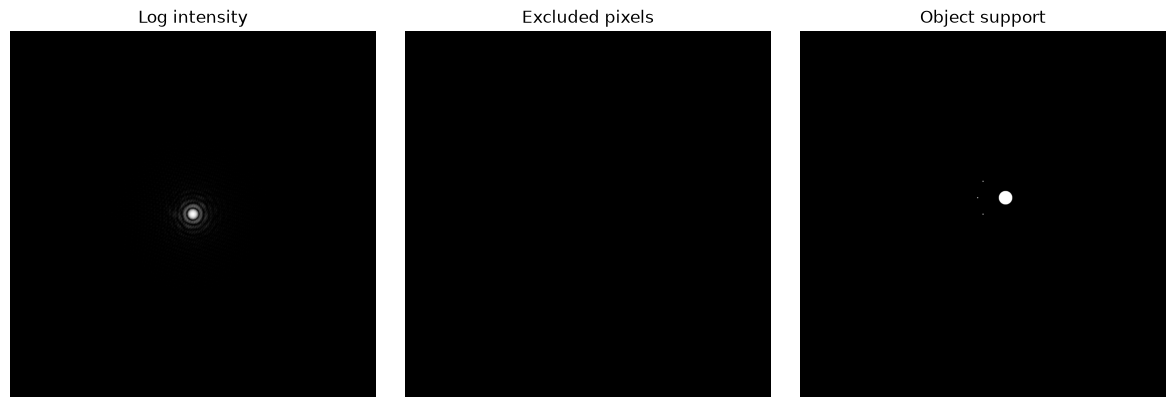

In [25]:
saved = wf.load_data_dict(SUPPORT_FILE)
support_source = np.asarray(saved["supportmask"])
pixel_source = np.asarray(saved["mask_pixel"]) != 0
if support_source.ndim != 2 or pixel_source.shape != support_source.shape:
    raise ValueError("Expected matching 2D supportmask and mask_pixel")
if not isinstance(BINNING, int) or BINNING < 1:
    raise ValueError("BINNING must be a positive integer")
source_shape = support_source.shape
supportmask = (support_source != 0).astype(np.uint8)

def load_average(scan_id):
    with h5py.File(AVERAGE_FOLDER / f"scan_{scan_id:04d}_avg.h5", "r") as handle:
        image = np.asarray(handle["image"][()]).squeeze()
    if image.shape != source_shape:
        raise ValueError(f"Scan {scan_id}: shape {image.shape} != support {source_shape}")
    return image.astype(np.float32)

dark_cache = {}
holograms, masks = [], []
for row in records:
    if row["dark_id"] not in dark_cache:
        dark_cache[row["dark_id"]] = load_average(row["dark_id"])
    raw = load_average(row["scan_id"])
    corrected = wf.center_image(raw - dark_cache[row["dark_id"]], DETECTOR_CENTER, cci)
    excluded = np.zeros(source_shape, dtype=bool)
    if USE_SAVED_PIXEL_MASK:
        excluded |= pixel_source
    excluded |= wf.center_image((raw >= SATURATION).astype(np.uint8), DETECTOR_CENTER, cci) != 0
    excluded |= ~np.isfinite(corrected)
    holograms.append((np.nan_to_num(corrected) / (500 * row["exposure_s"])).astype(np.float32))
    masks.append(excluded.astype(np.uint8))
del dark_cache
holograms = np.stack(holograms)
mask_pixel = np.stack(masks)
assert holograms.shape == mask_pixel.shape == (len(records), *source_shape)
print("Input stack:", holograms.shape, "support pixels:", supportmask.sum(),
      "masked detector fraction:", mask_pixel.mean())
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(np.log1p(np.maximum(holograms[0], 0)), cmap="gray")
axes[1].imshow(mask_pixel[0], cmap="gray")
axes[2].imshow(supportmask, cmap="gray")
for ax, title in zip(axes, ("Log intensity", "Excluded pixels", "Object support")):
    ax.set_title(title); ax.axis("off")
plt.tight_layout()

## Joint physical retrieval

Each energy has both polarizations in one magnetic state. The fit estimates an energy independent common object, charge and magnetic spectra, and a spatial magnetization map. With one state and no external scale anchor, the absolute charge offset and magnetization scale retain gauge freedom; inspect the returned `identifiable` and residual diagnostics before interpreting amplitudes quantitatively.

In [ ]:
states = [r["state"] for r in records]
energy_labels = [float(r["energy_eV"]) for r in records]
polarizations = [r["polarization"] for r in records]
illumination_labels = ["beam0"] * len(records)
recipe = universal.default_universal_phase_retrieval_recipe()
recipe.update(
    projection_model="physical_factorized",
    energy_values=energy_values,
    inner_mode=["ER"], inner_Nit=[5],
    warmup_mode=["ER"], warmup_Nit=[20],
    outer_iterations=30,
    physical_iterations=20,
    saturated_states=None,
    projection_every=len(records),
    projection_relaxation=0.5,
    projection_constraints_inside_support_only=True,
    zero_magnetization_outside_support=True,
    hologram_intensity_cutoff_vmin=-1,
    shuffle_observations=False,
    random_seed=0,
    binning=BINNING, crop=CROP, roi=ROI,
)
fields, warmup_fields, components, bsmasks, errors = universal.universal_phase_retrieval_algorithm(
    holograms, mask_pixel, supportmask,
    state_labels=states, energy_labels=energy_labels,
    polarization_coefficients=polarizations,
    illumination_labels=illumination_labels,
    universal_recipe=recipe,
)
supportmask_result = components["supportmask"]
mask_pixel_result = components["mask_pixel"]
roi_result = components["roi"]
print("Retrieval shape:", components["supportmask_used"].shape, "output shape:", supportmask_result.shape, "ROI:", roi_result)
print("Model:", components["projection_model"], "identifiable:", components.get("identifiable"))
print("Fit residual RMS:", components.get("fit_residual_rms"))
print("Field stack:", fields.shape, "charge spectrum:", np.shape(components["charge_response"]),
      "magnetic spectrum:", np.shape(components["magnetic_response"]))

Universal phase retrieval: dispatching 26 observations with projection_model='physical_factorized'
Universal phase retrieval: starting physical reconstruction with 26 observations, 13 energies, and 30 outer loops
Universal phase retrieval: starting independent warmup for 26 observations
  Warmup observation 1/26
  Warmup observation 2/26
  Warmup observation 3/26
  Warmup observation 4/26
  Warmup observation 5/26
  Warmup observation 6/26
  Warmup observation 7/26
  Warmup observation 8/26
  Warmup observation 9/26
  Warmup observation 10/26
  Warmup observation 11/26
  Warmup observation 12/26
  Warmup observation 13/26
  Warmup observation 14/26
  Warmup observation 15/26
  Warmup observation 16/26
  Warmup observation 17/26
  Warmup observation 18/26
  Warmup observation 19/26
  Warmup observation 20/26
  Warmup observation 21/26
  Warmup observation 22/26
  Warmup observation 23/26
  Warmup observation 24/26
  Warmup observation 25/26
  Warmup observation 26/26
Universal phase ret

## Inspect spectral and spatial components

Spectra are complex log object responses. Their real and imaginary parts describe amplitude and phase response in the library convention. The magnetization map is a fitted reduced spatial factor; its absolute scale is not anchored unless a saturated state or known magnetic spectrum is supplied.

In [ ]:
%matplotlib inline
charge = np.asarray(components["charge_response"])
magnetic = np.asarray(components["magnetic_response"])
magnetization = np.asarray(components["magnetization"])
common = np.asarray(components["common_log_objects"])[0]
model_energies = np.asarray(components["energy_names"], dtype=float)
order = np.argsort(model_energies)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0, 0].plot(model_energies[order], charge.real[order], "o-", label="real")
axes[0, 0].plot(model_energies[order], charge.imag[order], "o-", label="imag")
axes[0, 0].set_title("Charge response"); axes[0, 0].legend()
axes[0, 1].plot(model_energies[order], magnetic.real[order], "o-", label="real")
axes[0, 1].plot(model_energies[order], magnetic.imag[order], "o-", label="imag")
axes[0, 1].set_title("Magnetic response"); axes[0, 1].legend()
axes[0, 2].imshow(np.abs(np.exp(common)), cmap="gray"); axes[0, 2].set_title("Common exit-wave amplitude")
axes[1, 0].imshow(np.angle(np.exp(common)), cmap="twilight"); axes[1, 0].set_title("Common exit-wave phase")
axes[1, 1].imshow(magnetization[0], cmap="RdBu_r", vmin=-1, vmax=1); axes[1, 1].set_title("Magnetization: " + str(components["state_names"][0]))
axes[1, 2].imshow(supportmask_result, cmap="gray"); axes[1, 2].set_title("Support")
for ax in axes.flat: ax.axis("off")
for ax in (axes[0, 0], axes[0, 1]): ax.axis("on"); ax.set_xlabel("Photon energy (eV)")
plt.tight_layout()

In [ ]:
fig,ax=plt.subplots()
ax.plot(model_energies[order], charge.imag[order], "o-", label="real")

In [ ]:
%matplotlib inline
fig,ax=plt.subplots()
ax.imshow(np.abs(common)[380:460,85:170], cmap="gray")

In [ ]:

fig,ax=plt.subplots()
ax.imshow(magnetization[0][380:460,85:170], cmap="RdBu_r")

## Optional generic spectral baseline

This second run uses helicity averaged intensities and a rank one spectral projection. It gives a model independent static object and one energy dependent spatial mode for comparison. It does not estimate magnetization.

In [ ]:
baseline = None
if RUN_RANK_ONE_BASELINE:
    paired = {}
    for i, row in enumerate(records):
        paired.setdefault(row["energy_eV"], {})[row["polarization"]] = i
    if any(set(pair) != {-1, +1} for pair in paired.values()):
        raise ValueError("Every baseline energy needs one positive and one negative image")
    energies_baseline = sorted(paired)
    average_stack = np.stack([(holograms[paired[e][1]] + holograms[paired[e][-1]]) / 2
                              for e in energies_baseline])
    average_mask = np.stack([(mask_pixel[paired[e][1]] | mask_pixel[paired[e][-1]])
                             for e in energies_baseline])
    baseline_recipe = dict(recipe, projection_model="rank1_spectral", rank=1,
                           energy_values=np.asarray(energies_baseline))
    baseline = universal.universal_phase_retrieval_algorithm(
        average_stack, average_mask, supportmask,
        state_labels=["state0"] * len(energies_baseline),
        energy_labels=energies_baseline,
        polarization_coefficients=[1] * len(energies_baseline),
        illumination_labels=["beam0"] * len(energies_baseline),
        universal_recipe=baseline_recipe,
    )
    baseline_components = baseline[2]
    print("Baseline components:", sorted(baseline_components))
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(np.abs(np.exp(baseline_components["static_log_object"])), cmap="gray")
    ax[1].imshow(np.abs(baseline_components["spectral_spatial_map"]), cmap="magma")
    ax[2].plot(energies_baseline, np.abs(baseline_components["spectral_coefficients"]), "o-")
    for a, title in zip(ax, ("Static exit wave", "Spectral spatial mode", "Spectral coefficient")):
        a.set_title(title)
    plt.tight_layout()

## Save the reconstruction

Save a new HDF5 file; the source MAXIV support and recipe files remain untouched.

In [ ]:
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
with h5py.File(OUTPUT_FILE, "w") as out:
    out.attrs["workflow"] = "maxiv_hyperspectral_universal"
    out.attrs["recipe_json"] = json.dumps(recipe, default=lambda value: np.asarray(value).tolist())
    out.create_dataset("fields", data=np.asarray(fields), compression="gzip")
    out.create_dataset("bsmasks", data=np.asarray(bsmasks, dtype=np.uint8), compression="gzip")
    out.create_dataset("supportmask", data=supportmask_result, compression="gzip")
    out.create_dataset("supportmask_used", data=components["supportmask_used"], compression="gzip")
    out.create_dataset("mask_pixel", data=mask_pixel_result, compression="gzip")
    if roi_result is not None:
        out.create_dataset("roi", data=roi_result)
    out.create_dataset("energies_eV", data=model_energies)
    out.create_dataset("scan_ids", data=[r["scan_id"] for r in records])
    out.create_dataset("dark_ids_used", data=[r["dark_id"] for r in records])
    out.create_dataset("polarizations", data=polarizations)
    out.create_dataset("exposures_s", data=[r["exposure_s"] for r in records])
    out.create_dataset("states", data=np.asarray(states, dtype="S"))
    group = out.create_group("components")
    for key in ("common_log_objects", "charge_response", "magnetic_response", "magnetization"):
        group.create_dataset(key, data=np.asarray(components[key]), compression="gzip")
    group.attrs["identifiable"] = bool(components.get("identifiable", False))
    group.attrs["fit_residual_rms"] = float(components.get("fit_residual_rms", np.nan))
    if baseline is not None:
        other = out.create_group("rank_one_baseline")
        for key in ("static_log_object", "spectral_spatial_map", "spectral_coefficients"):
            other.create_dataset(key, data=np.asarray(baseline[2][key]), compression="gzip")
print("Saved", OUTPUT_FILE)